# Microstructure Stylized Facts: Bid-Ask Bounce and Liquidity

**Chapter 3: Market Microstructure**

**Docker image**: `ml4t`

## Purpose

Demonstrate two of §3.3's stylized facts using NASDAQ ITCH-derived trade
data: (i) bid-ask bounce as negative first-order autocorrelation in
tick-level returns, and (ii) the liquidity spectrum that motivates Chapter
19's price-impact model.

## Learning Objectives

After completing this notebook, you will be able to:
- Compute lag-1 autocorrelation of tick-level trade returns and explain why
  it is negative for typical equities (bid-ask bounce).
- Compare liquidity metrics (volume, dollar value, average trade size,
  intraday volatility) across high-, medium-, and low-liquidity tickers.
- Recognize when trade-price returns must be replaced with mid-price
  returns to avoid microstructure noise.

## Book reference

Section §3.3, *From Raw Messages to the Limit Order Book* — stylized-facts
subsection on bid-ask bounce.

## Prerequisites

- The canonical enriched-trade parquet at
  `output/ch03/nasdaq_itch/trading_activity/trades.parquet` and the matching
  `trade_summary.parquet` (used for ticker selection and the liquidity-spectrum
  section); both are produced by `05_itch_trading_activity`.
- For the order-arrival panel, parsed ITCH `A`/`F`/`X` parquets at the
  canonical `data/equities/market/microstructure/nasdaq_itch/messages/`
  path (output of `01_itch_parser`).

---

## Setup

In [1]:
"""Microstructure Stylized Facts — bid-ask bounce, order flow dynamics, and the liquidity spectrum."""

import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pyarrow.compute as pc
import pyarrow.dataset as ds
import seaborn as sns
from IPython.display import display  # noqa: F401

from utils.paths import get_output_dir

sns.set_style("whitegrid")

In [2]:
# Production defaults — Papermill injects overrides for CI
MAX_SYMBOLS = 0  # 0 = all

In [3]:
# Configuration - Unified output directory structure
# All ITCH-related outputs under a single chapter directory
from data.equities.loader import load_nasdaq_itch

NASDAQ_ITCH_OUTPUT = get_output_dir(3, "nasdaq_itch")

# Input: Parsed messages live under the canonical loader path (not under output/).
MESSAGE_DIR = load_nasdaq_itch(get_base_path=True)

# Input: Trade summary from notebook 05 (trading_activity_overview)
TRADING_ACTIVITY_DIR = NASDAQ_ITCH_OUTPUT / "trading_activity"

print(f"Input directory (messages): {MESSAGE_DIR}")
print(f"Input directory (trade summary): {TRADING_ACTIVITY_DIR}")

if not MESSAGE_DIR.exists():
    print(f"\nWARNING: Message directory not found: {MESSAGE_DIR}")
    print("   Run 01_itch_parser first.")

Input directory (messages): data/equities/market/microstructure/nasdaq_itch/messages
Input directory (trade summary): 03_market_microstructure/output/nasdaq_itch/trading_activity


## Load Trade Data

Load outputs from `05_itch_trading_activity`:
- `trade_summary.parquet`: Aggregated stats by ticker (for symbol selection)
- `trades.parquet`: Canonical tick-level trades (for analysis)

Using the canonical trades file ensures we include enriched E/C data
(executions with stock attribution added by notebook 01).

In [4]:
# Load trade summary and canonical trades from notebook 05
TRADE_SUMMARY_PATH = TRADING_ACTIVITY_DIR / "trade_summary.parquet"
TRADES_PATH = TRADING_ACTIVITY_DIR / "trades.parquet"

# Load trade summary for ticker selection
if TRADE_SUMMARY_PATH.exists():
    trade_summary = pl.read_parquet(TRADE_SUMMARY_PATH)
    # Sort explicitly by value to ensure correct selection
    trade_summary = trade_summary.sort("total_value", descending=True)
    num_syms = len(trade_summary)
    high_sym = trade_summary["ticker"][0]  # highest value
    mid_sym = trade_summary["ticker"][num_syms // 2]  # middle
    low_sym = trade_summary["ticker"][-1]  # lowest value
    print(f"Loaded trade summary: {num_syms} tickers")
else:
    # Fallback to common symbols if no summary available
    high_sym, mid_sym, low_sym = "AAPL", "INTC", "UGA"
    trade_summary = None
    print(f"Trade summary not found at {TRADE_SUMMARY_PATH}")
    print("Using fallback symbols (run 05_itch_trading_activity first for best results)")

# Load canonical trades (single source of truth for trade extraction)
if TRADES_PATH.exists():
    all_trades = pl.read_parquet(TRADES_PATH)
    data_available = True
    print(f"Loaded canonical trades: {len(all_trades):,} trades")
    if "msg_type" in all_trades.columns:
        msg_breakdown = all_trades.group_by("msg_type").len().sort("msg_type")
        print("  Message type breakdown:")
        for row in msg_breakdown.iter_rows():
            print(f"    {row[0]}: {row[1]:>12,}")
else:
    all_trades = None
    data_available = MESSAGE_DIR.exists()
    print(f"Canonical trades not found at {TRADES_PATH}")
    print("Run 05_itch_trading_activity first to generate trades.parquet")

print("\nSelected tickers for analysis:")
print(f"  High liquidity:   {high_sym}")
print(f"  Medium liquidity: {mid_sym}")
print(f"  Low liquidity:    {low_sym}")

Loaded trade summary: 8915 tickers
Loaded canonical trades: 10,194,361 trades
  Message type breakdown:
    C:      139,474
    E:    8,257,325
    P:    1,779,727
    Q:       17,835

Selected tickers for analysis:
  High liquidity:   TSLA
  Medium liquidity: QAT
  Low liquidity:    EDTXW


### Intraday Resampling
Resample tick-level trades to fixed-frequency bars for intraday pattern analysis.

In [5]:
def intraday_resample(trades_df: pl.DataFrame, ticker: str, freq: str = "5m") -> pl.DataFrame:
    """
    Filter trades for a single ticker and resample to intraday bars.

    Args:
        trades_df: Canonical trades DataFrame from notebook 05 (trades.parquet)
        ticker: Stock symbol to filter
        freq: Bar frequency (e.g., "5m", "15m", "30m", "1s")

    Returns:
        DataFrame with columns: timestamp, shares, value, price, vwap, trade_count
    """
    if trades_df is None or len(trades_df) == 0:
        return pl.DataFrame()

    # Filter to ticker
    df = trades_df.filter(pl.col("ticker") == ticker)
    if len(df) == 0:
        return pl.DataFrame()

    # Ensure we have required columns (compute value if missing)
    required = ["timestamp", "shares", "price"]
    if not all(c in df.columns for c in required):
        return pl.DataFrame()

    if "value" not in df.columns:
        df = df.with_columns((pl.col("shares") * pl.col("price")).alias("value"))

    df = df.select(["timestamp", "shares", "price", "value"]).sort("timestamp")

    # Resample to bars using group_by_dynamic
    bars = df.group_by_dynamic("timestamp", every=freq).agg(
        [
            pl.col("shares").sum().alias("shares"),
            pl.col("value").sum().alias("value"),
            pl.col("price").last().alias("price"),
            pl.len().alias("trade_count"),
        ]
    )

    # Calculate VWAP
    bars = bars.with_columns(
        pl.when(pl.col("shares") > 0)
        .then(pl.col("value") / pl.col("shares"))
        .otherwise(None)
        .alias("vwap")
    )

    bars = bars.drop_nulls(subset=["price"])
    return bars

## 6. Order Arrivals & Cancellations

We analyze the **Add** and **Cancel** message types to understand:
- How many orders are submitted vs. canceled
- Typical order sizes
- The cancellation rate (key microstructure metric)

In [6]:
def load_add_cancel_for_ticker(base_dir: Path, ticker: str) -> tuple[pl.DataFrame, pl.DataFrame]:
    """
    Load 'A' (Add), 'F' (Add with Mpid), and 'X' (Cancel) for a single ticker.

    For X (cancel) messages, prefers enriched files (from notebook 01's enrichment)
    which include the stock column. Raw X messages only have stock_locate.

    Returns tuple of (adds_df, cancels_df)
    """
    add_msgs = []
    for mt in ["A", "F"]:
        folder = base_dir / mt
        if not folder.is_dir():
            continue

        try:
            dset = ds.dataset(folder.as_posix(), format="parquet")

            # Try filtering by ticker or stock
            try:
                subset = dset.to_table(filter=pc.equal(pc.field("ticker"), ticker))
            except Exception:
                try:
                    subset = dset.to_table(filter=pc.equal(pc.field("stock"), ticker))
                except Exception:
                    continue

            if subset.num_rows > 0:
                add_msgs.append(pl.from_arrow(subset))
        except Exception:
            pass

    add_df = pl.concat(add_msgs, how="diagonal_relaxed") if add_msgs else pl.DataFrame()

    # Load cancels - prefer enriched X which has stock column
    cancel_df = pl.DataFrame()
    enriched_x = base_dir / "enriched" / "X.parquet"
    x_folder = base_dir / "X"

    if enriched_x.exists():
        # Use enriched X (has stock column from notebook 01 enrichment)
        try:
            df = pl.read_parquet(enriched_x)
            cancel_df = df.filter(pl.col("stock") == ticker)
        except Exception:
            pass
    elif x_folder.is_dir():
        # Fall back to raw X - but note: raw X lacks ticker column
        # This will likely return empty since filtering by ticker/stock won't work
        try:
            dset = ds.dataset(x_folder.as_posix(), format="parquet")
            try:
                sub_x = dset.to_table(filter=pc.equal(pc.field("ticker"), ticker))
            except Exception:
                try:
                    sub_x = dset.to_table(filter=pc.equal(pc.field("stock"), ticker))
                except Exception:
                    sub_x = None

            if sub_x and sub_x.num_rows > 0:
                cancel_df = pl.from_arrow(sub_x)
        except Exception:
            pass

    return add_df, cancel_df

### Analyze Order Flow for a Ticker
Compute order submission, cancellation, and size statistics for a given stock.

In [7]:
def analyze_order_flow_for_ticker(base_dir: Path, ticker: str) -> tuple[dict, pl.DataFrame]:
    """
    Analyze order flow patterns for a given ticker.

    Returns tuple of (results dict, standardized add orders DataFrame).
    """
    add_df, cancel_df = load_add_cancel_for_ticker(base_dir, ticker)

    if len(add_df) == 0:
        print(f"{ticker}: No 'Add Order' messages found.")
        return {}, pl.DataFrame()

    # Track whether the cancel-rate proxy can actually be computed. Raw X
    # messages lack a 'stock' column, so cancels can only be attributed to a
    # ticker via the enriched X file produced by notebook 01. If that file is
    # absent, cancel_df comes back empty and the proxy collapses to 0 — a
    # spurious zero, not a real "no cancels" result. The summary printer
    # surfaces this so the reader doesn't read the zero as a finding.
    cancel_data_available = (base_dir / "enriched" / "X.parquet").exists()

    results = {"ticker": ticker, "cancel_data_available": cancel_data_available}

    # Standardize columns using Polars (vectorized)
    # Cast to string first to handle bytes/string mix
    if "buy_sell_indicator" in add_df.columns:
        add_df = add_df.with_columns(pl.col("buy_sell_indicator").cast(pl.Utf8).alias("_side_str"))
        add_df = add_df.with_columns(
            pl.when(pl.col("_side_str") == "B")
            .then(1)
            .when(pl.col("_side_str") == "S")
            .then(-1)
            .otherwise(0)
            .alias("side")
        ).drop("_side_str")

    if "shares" in add_df.columns:
        add_df = add_df.with_columns(pl.col("shares").cast(pl.Float64))

    # Calculate cancellation rate
    if len(cancel_df) > 0 and "cancelled_shares" in cancel_df.columns:
        total_canceled = cancel_df.select(pl.col("cancelled_shares").sum()).item()
    elif len(cancel_df) > 0 and "canceled_shares" in cancel_df.columns:
        total_canceled = cancel_df.select(pl.col("canceled_shares").sum()).item()
    else:
        total_canceled = 0

    total_shares = add_df.select(pl.col("shares").sum()).item() if "shares" in add_df.columns else 0
    # PROXY for cancellation rate: canceled_shares / submitted_shares
    # Can exceed 1.0 due to replaces (U) or multiple partial cancels on same shares
    cancel_rate_proxy = total_canceled / total_shares if total_shares > 0 else 0

    results["total_orders"] = len(add_df)
    results["total_shares_submitted"] = total_shares
    results["total_shares_canceled"] = total_canceled
    results["cancel_rate_proxy"] = cancel_rate_proxy

    return results, add_df

### Print Order Flow Summary
Display order flow statistics including counts, cancel rates, and size distribution.

In [8]:
def print_order_flow_summary(results: dict, add_df: pl.DataFrame) -> None:
    """Print order flow summary statistics."""
    if not results:
        return

    # Order size distribution
    if "shares" in add_df.columns:
        size_stats = add_df.select(
            [
                pl.col("shares").mean().alias("mean"),
                pl.col("shares").median().alias("median"),
            ]
        ).row(0)
        results["avg_order_size"] = size_stats[0]
        results["median_order_size"] = size_stats[1]

    ticker = results["ticker"]
    print(f"\n{'=' * 50}")
    print(f"Order Flow Analysis: {ticker}")
    print(f"{'=' * 50}")
    print(f"Total Orders:       {results['total_orders']:>12,}")
    print(f"Shares Submitted:   {results['total_shares_submitted']:>12,.0f}")
    if results.get("cancel_data_available", True):
        print(f"Shares Canceled:    {results['total_shares_canceled']:>12,.0f}")
        print(f"Cancel Rate (proxy):{results['cancel_rate_proxy']:>12.1%}")
        if results["cancel_rate_proxy"] > 1.0:
            print("  (>100% can occur due to replaces or multiple partial cancels)")
    else:
        # The cancel proxy needs the enriched X file produced by notebook 01.
        # When it is missing, raw X parquet lacks a 'stock' column so the
        # filtered cancel_df is empty and total_canceled trivially equals 0.
        # Print this loudly so the reader does not mistake the zero for a
        # microstructure finding.
        print(f"Shares Canceled:    {'N/A':>12}")
        print(f"Cancel Rate (proxy):{'N/A':>12}")
        print(
            "  (enriched/X.parquet not found — re-run notebook 01 to enable the cancel-rate proxy)"
        )

    if "avg_order_size" in results:
        print("\nOrder Size Statistics:")
        print(f"  Mean:   {results['avg_order_size']:>10,.0f} shares")
        print(f"  Median: {results['median_order_size']:>10,.0f} shares")

### Plot Order Flow
Visualize hourly order arrivals and print top order sizes for a ticker.

In [9]:
def plot_order_flow(add_df: pl.DataFrame, ticker: str) -> None:
    """Plot hourly order arrivals and print top order sizes."""
    if len(add_df) == 0:
        return

    # Plot order arrivals by time
    if "timestamp" in add_df.columns:
        add_with_ts = add_df.filter(pl.col("timestamp").is_not_null())
        if len(add_with_ts) > 0:
            arrivals = (
                add_with_ts.sort("timestamp")
                .group_by_dynamic("timestamp", every="1h")
                .agg(pl.len().alias("count"))
            )

            arrivals_pd = arrivals.to_pandas()
            # Use the actual clock hour (HH:MM ET) for the x-axis labels rather than
            # 0..N positional indices. ITCH timestamps are nanoseconds since session
            # midnight ET (the exchange's local clock); strftime renders them directly.
            hour_labels = [ts.strftime("%H:%M") for ts in arrivals_pd["timestamp"]]
            fig, ax = plt.subplots(figsize=(10, 4))
            ax.bar(range(len(arrivals_pd)), arrivals_pd["count"], color="steelblue")
            ax.set_xticks(range(len(arrivals_pd)))
            ax.set_xticklabels(hour_labels, rotation=45, ha="right")
            ax.set_title(f"{ticker} - Order Arrivals by Hour")
            ax.set_xlabel("Hour of session (ET)")
            ax.set_ylabel("Number of Orders")
            plt.tight_layout()
            plt.show()

    # Top order sizes
    if "shares" in add_df.columns:
        size_counts = (
            add_df.group_by("shares")
            .agg(pl.len().alias("count"))
            .sort("count", descending=True)
            .head(10)
        )
        print("\nTop 10 Order Sizes:")
        for row in size_counts.iter_rows():
            print(f"  {row[0]:>8,.0f} shares: {row[1]:>6,} orders")


Order Flow Analysis: TSLA
Total Orders:            422,317
Shares Submitted:     33,639,088
Shares Canceled:             N/A
Cancel Rate (proxy):         N/A
  (enriched/X.parquet not found — re-run notebook 01 to enable the cancel-rate proxy)

Order Size Statistics:
  Mean:           80 shares
  Median:        100 shares


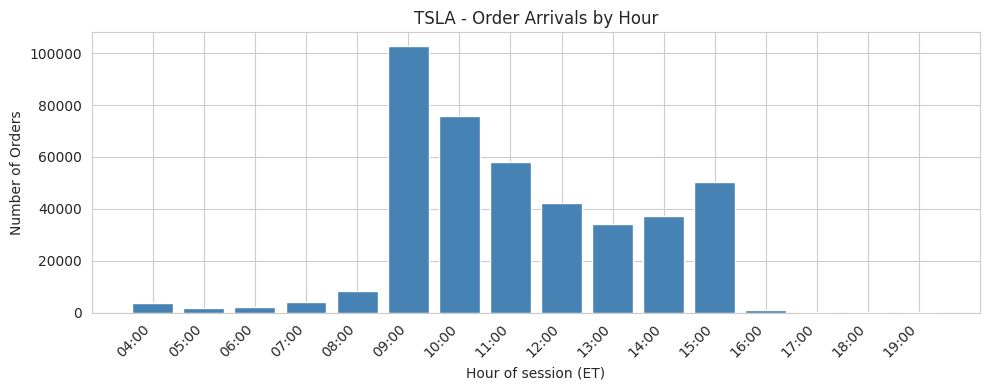


Top 10 Order Sizes:
       100 shares: 224,112 orders
         1 shares: 29,176 orders
        15 shares: 14,420 orders
        10 shares: 13,683 orders
        30 shares: 11,410 orders
         2 shares: 10,264 orders
         5 shares:  9,394 orders
        20 shares:  9,315 orders
        50 shares:  8,375 orders
        14 shares:  7,753 orders


In [10]:
if MESSAGE_DIR.exists() and data_available:
    flow_results, flow_add_df = analyze_order_flow_for_ticker(MESSAGE_DIR, high_sym)
    print_order_flow_summary(flow_results, flow_add_df)
    plot_order_flow(flow_add_df, high_sym)


Order Flow Analysis: QAT
Total Orders:              4,147
Shares Submitted:     10,063,862
Shares Canceled:             N/A
Cancel Rate (proxy):         N/A
  (enriched/X.parquet not found — re-run notebook 01 to enable the cancel-rate proxy)

Order Size Statistics:
  Mean:        2,427 shares
  Median:      3,100 shares


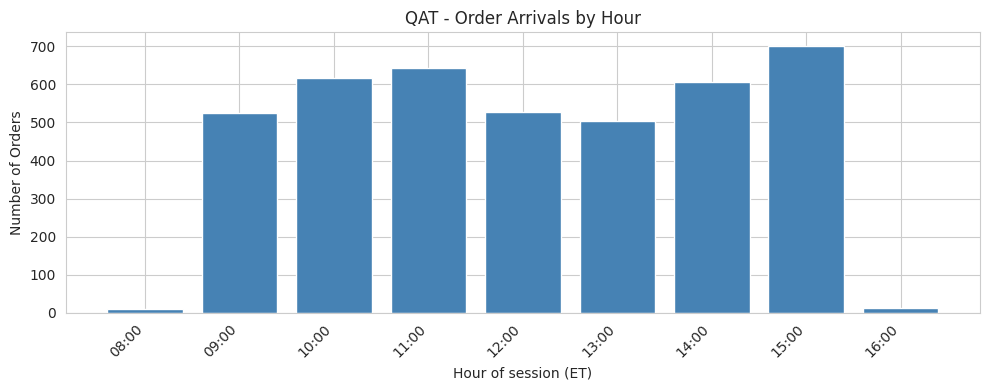


Top 10 Order Sizes:
       500 shares:    843 orders
       100 shares:    562 orders
       200 shares:    282 orders
     4,300 shares:    109 orders
     4,500 shares:    108 orders
     3,500 shares:    107 orders
     4,200 shares:    105 orders
     4,100 shares:    105 orders
     4,000 shares:    104 orders
     4,400 shares:    103 orders


In [11]:
if MESSAGE_DIR.exists() and data_available:
    flow_results, flow_add_df = analyze_order_flow_for_ticker(MESSAGE_DIR, mid_sym)
    print_order_flow_summary(flow_results, flow_add_df)
    plot_order_flow(flow_add_df, mid_sym)

### 7.2 The Bid-Ask Bounce

A fundamental microstructure phenomenon: trade prices bounce between bid and ask,
creating **negative autocorrelation** in tick-level returns. This is why:
- Mid-price returns are preferred over trade-price returns
- Tick-level "momentum" signals fail
- The Roll (1984) spread estimator works

**Implication for Chapter 8**: Always compute returns from mid-prices, not trade prices.

In [12]:
def compute_tick_autocorrelation(trades_df: pl.DataFrame, ticker: str, max_lags: int = 20) -> dict:
    """
    Compute autocorrelation of tick-level returns to demonstrate bid-ask bounce.

    Note: We use 1-second bars as a proxy for tick data. True tick-by-tick analysis
    would use individual trade prices, but the bounce effect is still visible at
    1-second resolution for liquid stocks.

    Args:
        trades_df: Canonical trades DataFrame from notebook 05
        ticker: Stock symbol to analyze
        max_lags: Maximum number of lags to compute

    Returns:
        Dict with autocorrelation results
    """
    # Use 1-second bars as proxy for ticks (true tick data would be even noisier)
    bars = intraday_resample(trades_df, ticker, freq="1s")
    if len(bars) < 100:
        return {}

    # Compute returns in basis points (1bp = 0.01% = 0.0001)
    # pct_change() returns decimal (e.g., 0.01 = 1%), so multiply by 10000 for bps
    bars = bars.with_columns(
        (pl.col("price").pct_change() * 10000).alias("return_bps"),
    ).drop_nulls()

    returns = bars["return_bps"].to_numpy()

    # Compute autocorrelations
    n = len(returns)
    mean_r = np.mean(returns)
    var_r = np.var(returns)

    autocorrs = []
    for lag in range(1, max_lags + 1):
        if n - lag < 10:
            break
        cov = np.mean((returns[lag:] - mean_r) * (returns[:-lag] - mean_r))
        autocorrs.append(cov / var_r if var_r > 0 else 0)

    return {
        "ticker": ticker,
        "autocorrs": autocorrs,
        "n_obs": n,
        "lag1_autocorr": autocorrs[0] if autocorrs else 0,
    }

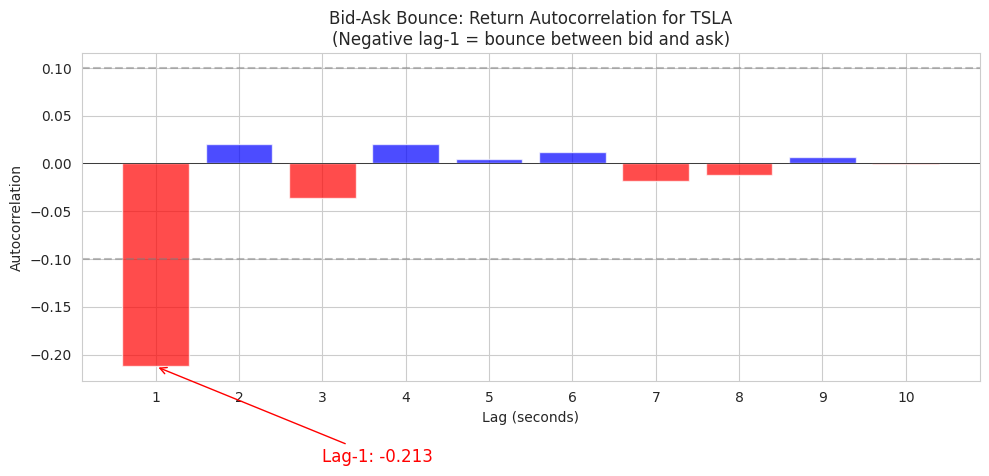


Bid-Ask Bounce Analysis for TSLA:
  Lag-1 autocorrelation: -0.2125
  (Negative value confirms bounce between bid and ask)

  Implication: Use mid-price returns, not trade-price returns!


In [13]:
if data_available and all_trades is not None:
    # Compute autocorrelation for high-liquidity ticker
    bounce_result = compute_tick_autocorrelation(all_trades, high_sym, max_lags=10)

    if bounce_result and bounce_result["autocorrs"]:
        lags = list(range(1, len(bounce_result["autocorrs"]) + 1))
        autocorrs = bounce_result["autocorrs"]

        fig, ax = plt.subplots(figsize=(10, 5))

        colors = ["red" if ac < 0 else "blue" for ac in autocorrs]
        ax.bar(lags, autocorrs, color=colors, alpha=0.7)
        ax.axhline(0, color="black", linewidth=0.5)
        ax.axhline(-0.1, color="gray", linestyle="--", alpha=0.5)
        ax.axhline(0.1, color="gray", linestyle="--", alpha=0.5)

        ax.set_xlabel("Lag (seconds)")
        ax.set_ylabel("Autocorrelation")
        ax.set_title(
            f"Bid-Ask Bounce: Return Autocorrelation for {high_sym}\n"
            f"(Negative lag-1 = bounce between bid and ask)"
        )
        ax.set_xticks(lags)

        # Add annotation
        ax.annotate(
            f"Lag-1: {autocorrs[0]:.3f}",
            xy=(1, autocorrs[0]),
            xytext=(3, autocorrs[0] - 0.1),
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=12,
            color="red",
        )

        plt.tight_layout()
        plt.show()

        print(f"\nBid-Ask Bounce Analysis for {high_sym}:")
        print(f"  Lag-1 autocorrelation: {autocorrs[0]:.4f}")
        print("  (Negative value confirms bounce between bid and ask)")
        print("\n  Implication: Use mid-price returns, not trade-price returns!")

### 7.3 The Liquidity Spectrum: From Blue Chips to Small Caps

One of the most important microstructure insights: **liquidity varies enormously**
across stocks. A 1000-share order has near-zero impact on AAPL but can move
an illiquid stock by 50+ basis points.

This comparison foreshadows the price impact discussion in Chapter 19.

In [14]:
def compare_liquidity_metrics(trades_df: pl.DataFrame, tickers: list[str]) -> pl.DataFrame:
    """
    Compare key liquidity metrics across tickers.

    Args:
        trades_df: Canonical trades DataFrame from notebook 05
        tickers: List of stock symbols to compare

    Returns:
        DataFrame with liquidity metrics per ticker
    """
    results = []

    for ticker in tickers:
        bars = intraday_resample(trades_df, ticker, freq="1m")
        if len(bars) < 10:
            continue

        # Compute metrics
        total_volume = bars["shares"].sum()
        total_value = bars["value"].sum()
        avg_trade_size = (
            total_volume / bars["trade_count"].sum() if bars["trade_count"].sum() > 0 else 0
        )

        # Compute volatility (1-minute return std), winsorized at the 1st/99th
        # percentile so a single mis-printed tick in a thinly traded name does not
        # dominate the estimate — raw ITCH prints occasionally carry bad prices.
        returns_bps = (
            bars.with_columns((pl.col("price").pct_change() * 10000).alias("return_bps"))[
                "return_bps"
            ]
            .drop_nulls()
            .to_numpy()
        )
        if len(returns_bps) >= 5:
            lo, hi = np.percentile(returns_bps, [1, 99])
            volatility = float(np.std(np.clip(returns_bps, lo, hi)))
        else:
            volatility = float("nan")

        # Price range as the 5th-95th percentile spread relative to the median bar
        # price. The raw max-min range is corrupted by the same single bad prints.
        prices = bars["price"].to_numpy()
        price_range = (
            (np.percentile(prices, 95) - np.percentile(prices, 5)) / np.median(prices) * 100
        )

        results.append(
            {
                "ticker": ticker,
                "total_volume": total_volume,
                "total_value": total_value,
                "avg_trade_size": avg_trade_size,
                "volatility_bps": volatility,
                "price_range_pct": price_range,
                "n_trades": bars["trade_count"].sum(),
            }
        )

    return pl.DataFrame(results)

In [15]:
if data_available and all_trades is not None:
    # Select stocks spanning the liquidity spectrum. We draw the tiers from the
    # *tradeable* universe — names with enough activity to form intraday bars —
    # because the long tail of the ITCH session (thousands of tickers with only a
    # handful of prints) cannot be resampled to one-minute bars and would drop out.
    MIN_TRADES = 500  # floor that guarantees each tier resamples to many 1-min bars
    if trade_summary is not None:
        tradeable = trade_summary.filter(pl.col("trade_count") >= MIN_TRADES)
        n_pool = len(tradeable)
        if n_pool >= 5:
            # `tradeable` is sorted by total_value descending; span it evenly.
            tier_idx = [0, n_pool // 4, n_pool // 2, 3 * n_pool // 4, n_pool - 1]
            spectrum_tickers = [tradeable["ticker"][i] for i in tier_idx]
        elif n_pool > 0:
            spectrum_tickers = tradeable["ticker"].to_list()
        else:
            spectrum_tickers = trade_summary["ticker"].to_list()
    else:
        # Fallback: well-known tickers across the liquidity spectrum
        spectrum_tickers = ["AAPL", "MSFT", "INTC", "AMD", "UGA"]

    liquidity_comparison = compare_liquidity_metrics(all_trades, spectrum_tickers)

    kept = liquidity_comparison["ticker"].to_list() if len(liquidity_comparison) else []
    dropped = [t for t in spectrum_tickers if t not in kept]
    if dropped:
        print(f"Note: dropped {', '.join(dropped)} (too few one-minute bars to compare).\n")

    if len(liquidity_comparison) > 0:
        # Sort by volume
        liquidity_comparison = liquidity_comparison.sort("total_volume", descending=True)

        print("=" * 80)
        print("LIQUIDITY SPECTRUM: From Blue Chips to Small Caps")
        print("=" * 80)
        print(
            f"{'Ticker':<8} {'Volume':>12} {'Value ($M)':>12} {'Avg Trade':>10} {'Volatility':>12} {'Price Range':>12}"
        )
        print("-" * 80)

        for row in liquidity_comparison.iter_rows(named=True):
            print(
                f"{row['ticker']:<8} {row['total_volume']:>12,.0f} {row['total_value'] / 1e6:>12.1f} "
                f"{row['avg_trade_size']:>10.0f} {row['volatility_bps']:>11.1f}bp {row['price_range_pct']:>11.2f}%"
            )

LIQUIDITY SPECTRUM: From Blue Chips to Small Caps
Ticker         Volume   Value ($M)  Avg Trade   Volatility  Price Range
--------------------------------------------------------------------------------
TSLA        7,745,829       4966.4         51        13.5bp        2.30%
PSTG          276,746          5.1         96         8.7bp        2.23%
GNMX          164,153          0.0        215        78.9bp        5.70%
APH           158,418         16.1         47         5.6bp        1.70%
AKR            66,759          1.7         51         6.5bp        1.72%


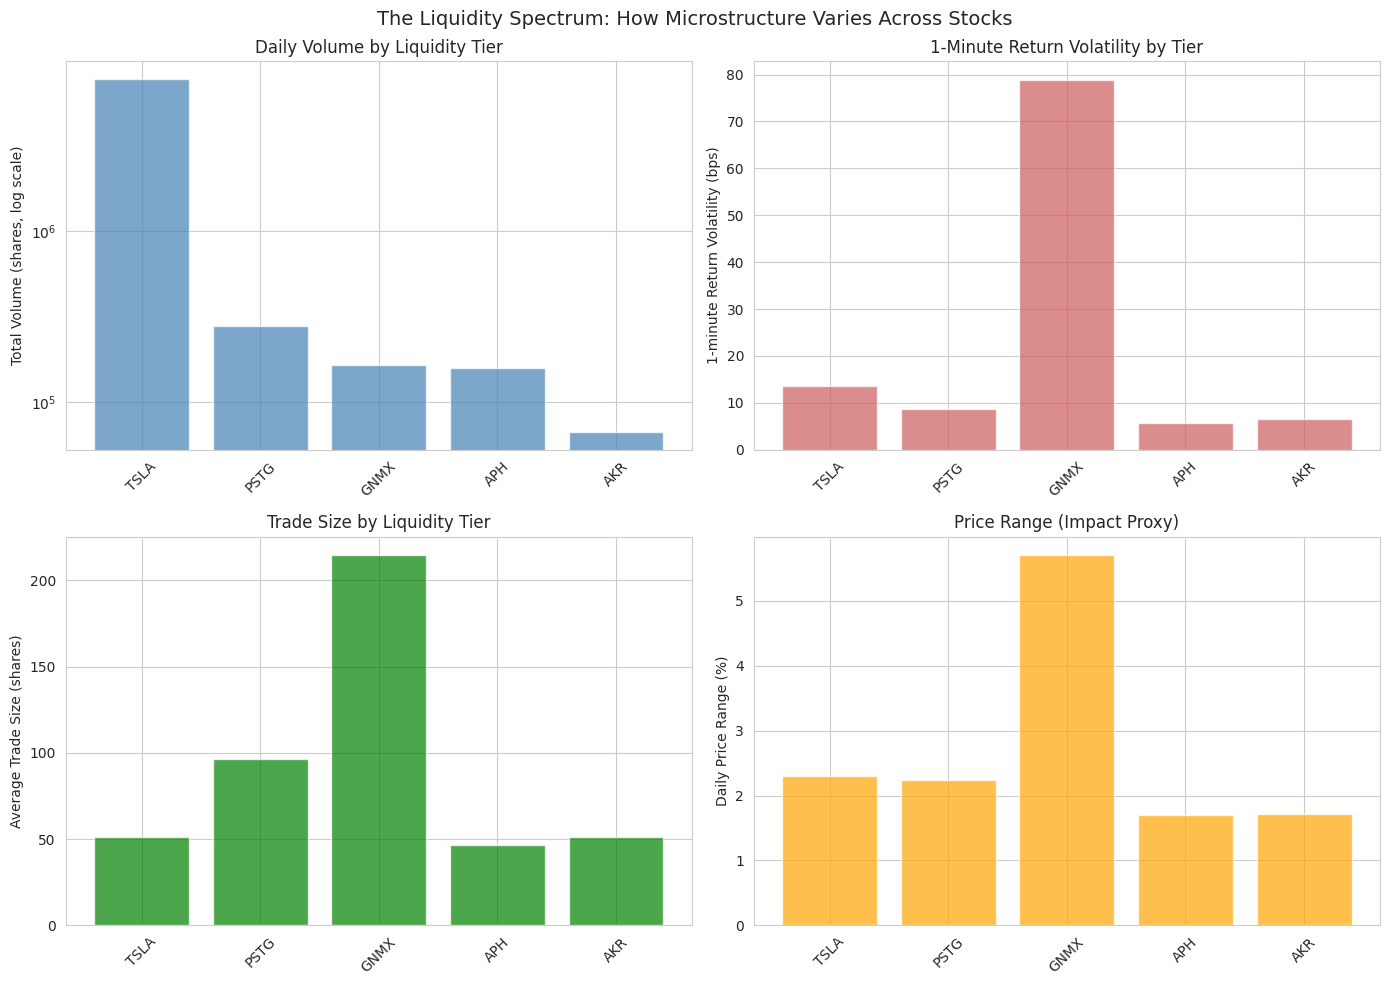

In [16]:
# Liquidity spectrum visualization
if data_available and all_trades is not None and len(liquidity_comparison) > 0:
    tickers = liquidity_comparison["ticker"].to_list()
    volumes = liquidity_comparison["total_volume"].to_numpy()
    volatilities = liquidity_comparison["volatility_bps"].to_numpy()
    trade_sizes = liquidity_comparison["avg_trade_size"].to_numpy()
    price_ranges = liquidity_comparison["price_range_pct"].to_numpy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].bar(tickers, volumes, color="steelblue", alpha=0.7)
    axes[0, 0].set_yscale("log")
    axes[0, 0].set_ylabel("Total Volume (shares, log scale)")
    axes[0, 0].set_title("Daily Volume by Liquidity Tier")
    axes[0, 0].tick_params(axis="x", rotation=45)

    axes[0, 1].bar(tickers, volatilities, color="indianred", alpha=0.7)
    axes[0, 1].set_ylabel("1-minute Return Volatility (bps)")
    axes[0, 1].set_title("1-Minute Return Volatility by Tier")
    axes[0, 1].tick_params(axis="x", rotation=45)

    axes[1, 0].bar(tickers, trade_sizes, color="green", alpha=0.7)
    axes[1, 0].set_ylabel("Average Trade Size (shares)")
    axes[1, 0].set_title("Trade Size by Liquidity Tier")
    axes[1, 0].tick_params(axis="x", rotation=45)

    axes[1, 1].bar(tickers, price_ranges, color="orange", alpha=0.7)
    axes[1, 1].set_ylabel("Daily Price Range (%)")
    axes[1, 1].set_title("Price Range (Impact Proxy)")
    axes[1, 1].tick_params(axis="x", rotation=45)

    plt.suptitle("The Liquidity Spectrum: How Microstructure Varies Across Stocks", fontsize=14)
    plt.tight_layout()
    plt.show()

In [17]:
# Liquidity ratio summary
if data_available and all_trades is not None and len(liquidity_comparison) >= 2:
    share_ratio = volumes[0] / volumes[-1] if volumes[-1] > 0 else float("inf")
    values = liquidity_comparison["total_value"].to_numpy()
    value_ratio = values[0] / values[-1] if values[-1] > 0 else float("inf")

    print("Key Insight:")
    print(f"  Share-volume ratio (most vs least active): {share_ratio:,.0f}x")
    print(f"  Dollar-value ratio (most vs least active):  {value_ratio:,.0f}x")
    print("\n  → Turnover spans orders of magnitude across the spectrum, but 1-minute")
    print("    return volatility does not track liquidity monotonically — it is driven")
    print("    by name-specific factors and spikes only at the micro-cap extreme.")
    print("  → Execution-cost magnitudes motivate the price impact analysis in Chapter 19.")

Key Insight:
  Share-volume ratio (most vs least active): 116x
  Dollar-value ratio (most vs least active):  2,981x

  → Turnover spans orders of magnitude across the spectrum, but 1-minute
    return volatility does not track liquidity monotonically — it is driven
    by name-specific factors and spikes only at the micro-cap extreme.
  → Execution-cost magnitudes motivate the price impact analysis in Chapter 19.



## 8. Key Takeaways

### Market Microstructure Insights

1. **Volume Concentration**: A small number of tickers account for most trading activity.
   The top 50 stocks account for ~46% of total dollar volume (see `05_itch_trading_activity`).

2. **Intraday U-Shape**: Volume and trading activity follow a characteristic pattern—high
   at open/close, low at midday. This affects optimal execution timing.

3. **Bid-Ask Bounce**: Trade prices bounce between bid and ask, creating negative
   autocorrelation at tick level. Use mid-price returns for ML features.

4. **Liquidity Spectrum**: Turnover spans orders of magnitude across the tiers in
   this sample — dollar value runs into the thousands-fold range from the most to
   least active name (see the comparison above). Intraday return volatility, by
   contrast, does not track liquidity monotonically: the most active name is more
   volatile than the mid-tier, and only the micro-cap extreme stands out. Volatility
   reflects name-specific factors, not liquidity alone. Execution-cost magnitudes
   across liquidity tiers are not estimated here; price-impact modelling is the
   subject of Chapter 19.

5. **Cancellation Rates**: High cancellation rates (>90%) are normal for modern markets,
   reflecting continuous quote adjustment by market makers.

### Bridge to Later Chapters

| Stylized Fact | Chapter 8 Application | Chapter 19 Application |
|---------------|----------------------|------------------------|
| **Intraday U-shape** | Time-of-day features | Execution timing |
| **Bid-ask bounce** | Mid-price return targets | Transaction cost models |
| **Liquidity spectrum** | Liquidity features | Price impact estimation |
| **Order flow imbalance** | OFI features | - |

### Next Steps

- **`04_itch_order_lifecycle_analysis`**: Deep dive into why ~96% of orders cancel
- **`02_itch_lob_reconstruction`**: Build the LOB from message events
- **`16_itch_information_bars`**: Convert ticks to ML-ready bars

---

**References**:
- Harris, L. (2003). *Trading and Exchanges: Market Microstructure for Practitioners*.
- Roll, R. (1984). "A Simple Implicit Measure of the Effective Bid-Ask Spread."
- Cont, R., Kukanov, A., & Stoikov, S. (2014). "The Price Impact of Order Book Events."

---

## Reference

Bouchaud, J.-P., Bonart, J., Donier, J., & Gould, M. (2018).
*Trades, Quotes and Prices: Financial Markets Under the Microscope*.
Cambridge University Press.
[https://doi.org/10.1017/9781009028943](https://doi.org/10.1017/9781009028943)